In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [112]:
# Load the fuel consumption dataset into a pandas DataFrame
fc_dataset = pd.read_csv("Fuel_Consumption_2000-2022.csv")


In [113]:
# Display the first rows to inspect the dataset structure
fc_dataset.head()


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198


In [114]:
# Keep only numeric model features and the target emission column
feature_data = fc_dataset.drop(columns=[
    "YEAR", "MAKE", "MODEL", "VEHICLE CLASS", "FUEL", "TRANSMISSION"
])


In [115]:
# Check the cleaned feature set
feature_data.head()


,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,1.6,4,9.2,6.7,8.1,35,186
1,1.6,4,8.5,6.5,7.6,37,175
2,3.2,6,12.2,7.4,10.0,28,230
3,3.5,6,13.4,9.2,11.5,25,264
4,1.8,4,10.0,7.0,8.6,33,198


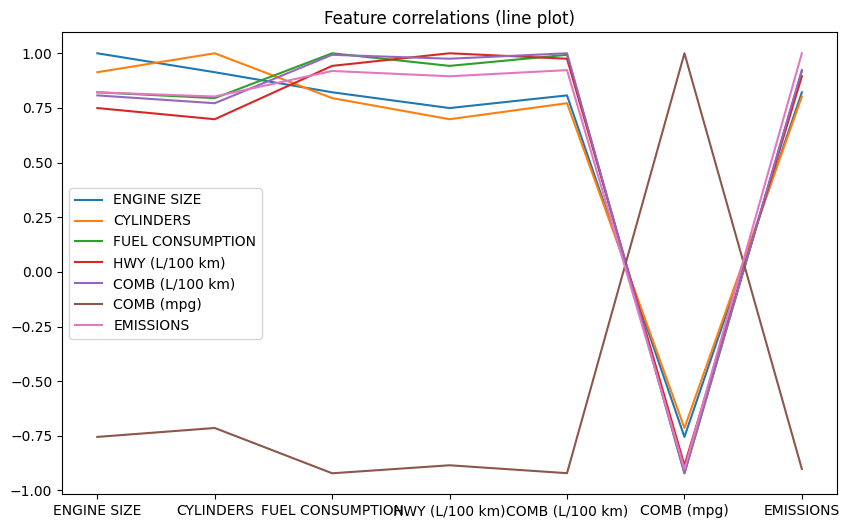

In [116]:
# Visualize correlations between remaining numeric variables
feature_data.corr().plot(kind="line", figsize=(10, 6))
plt.title("Feature correlations (line plot)")
plt.show()


In [117]:
# Print numeric correlation values for reference
print(feature_data.corr())


                  ENGINE SIZE  CYLINDERS  FUEL CONSUMPTION  HWY (L/100 km)  \
ENGINE SIZE          1.000000   0.913377          0.821605        0.749394   
CYLINDERS            0.913377   1.000000          0.794943        0.698344   
FUEL CONSUMPTION     0.821605   0.794943          1.000000        0.942351   
HWY (L/100 km)       0.749394   0.698344          0.942351        1.000000   
COMB (L/100 km)      0.807316   0.771587          0.992960        0.975014   
COMB (mpg)          -0.755002  -0.714215         -0.921361       -0.884744   
EMISSIONS            0.821285   0.802176          0.919101        0.894781   

                  COMB (L/100 km)  COMB (mpg)  EMISSIONS  
ENGINE SIZE              0.807316   -0.755002   0.821285  
CYLINDERS                0.771587   -0.714215   0.802176  
FUEL CONSUMPTION         0.992960   -0.921361   0.919101  
HWY (L/100 km)           0.975014   -0.884744   0.894781  
COMB (L/100 km)          1.000000   -0.920915   0.922983  
COMB (mpg)           

In [118]:
# No additional columns are dropped here after inspection
# This cell is kept for structure and future adjustments


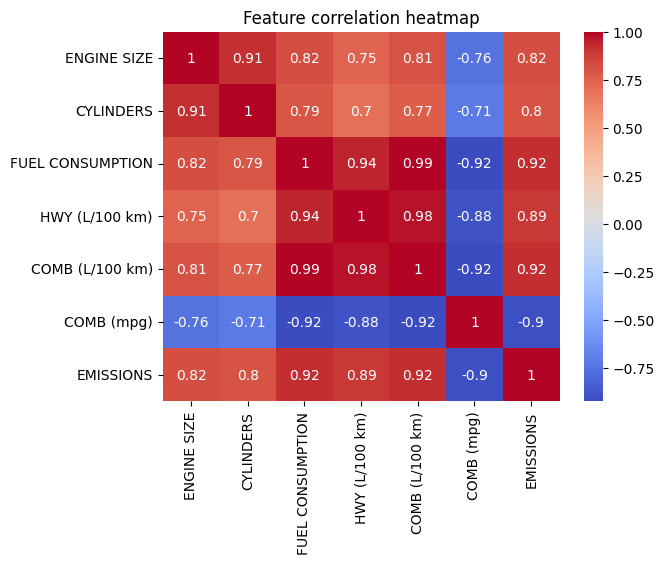

In [119]:
# Show the correlation heatmap
sns.heatmap(feature_data.corr(), cmap="coolwarm", annot=True)
plt.title("Feature correlation heatmap")
plt.show()


In [120]:
# Remove highly correlated or redundant variables before modeling
feature_data = feature_data.drop(columns=["HWY (L/100 km)", "FUEL CONSUMPTION"])


In [121]:
# Confirm the remaining features after dropping columns
feature_data


,ENGINE SIZE,CYLINDERS,COMB (L/100 km),COMB (mpg),EMISSIONS
0,1.6,4,8.1,35,186
1,1.6,4,7.6,37,175
2,3.2,6,10.0,28,230
3,3.5,6,11.5,25,264
4,1.8,4,8.6,33,198
...,...,...,...,...,...
22551,2.0,4,9.4,30,219
22552,2.0,4,9.4,30,219
22553,2.0,4,9.9,29,232
22554,2.0,4,10.1,28,236


In [122]:
# Evaluate the updated correlation matrix again
feature_data.corr()


,ENGINE SIZE,CYLINDERS,COMB (L/100 km),COMB (mpg),EMISSIONS
ENGINE SIZE,1.000000,0.913377,0.807316,-0.755002,0.821285
CYLINDERS,0.913377,1.000000,0.771587,-0.714215,0.802176
COMB (L/100 km),0.807316,0.771587,1.000000,-0.920915,0.922983
COMB (mpg),-0.755002,-0.714215,-0.920915,1.000000,-0.901844
EMISSIONS,0.821285,0.802176,0.922983,-0.901844,1.000000


In [123]:
# Print the correlation matrix again after dropping columns
print(feature_data.corr())


                 ENGINE SIZE  CYLINDERS  COMB (L/100 km)  COMB (mpg)  \
ENGINE SIZE         1.000000   0.913377         0.807316   -0.755002   
CYLINDERS           0.913377   1.000000         0.771587   -0.714215   
COMB (L/100 km)     0.807316   0.771587         1.000000   -0.920915   
COMB (mpg)         -0.755002  -0.714215        -0.920915    1.000000   
EMISSIONS           0.821285   0.802176         0.922983   -0.901844   

                 EMISSIONS  
ENGINE SIZE       0.821285  
CYLINDERS         0.802176  
COMB (L/100 km)   0.922983  
COMB (mpg)       -0.901844  
EMISSIONS         1.000000  


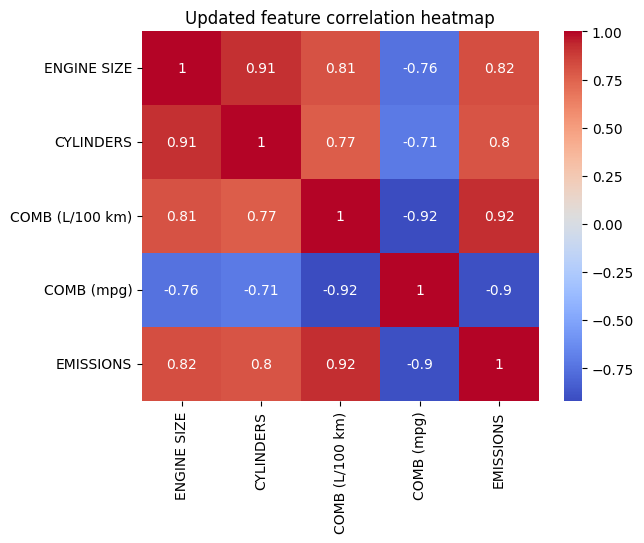

In [124]:
# Display the heatmap again to inspect the updated feature relationships
sns.heatmap(feature_data.corr(), cmap="coolwarm", annot=True)
plt.title("Updated feature correlation heatmap")
plt.show()


In [125]:
# Show the final feature set before training
feature_data


,ENGINE SIZE,CYLINDERS,COMB (L/100 km),COMB (mpg),EMISSIONS
0,1.6,4,8.1,35,186
1,1.6,4,7.6,37,175
2,3.2,6,10.0,28,230
3,3.5,6,11.5,25,264
4,1.8,4,8.6,33,198
...,...,...,...,...,...
22551,2.0,4,9.4,30,219
22552,2.0,4,9.4,30,219
22553,2.0,4,9.9,29,232
22554,2.0,4,10.1,28,236


In [126]:
# Drop the combined MPG column because it overlaps with other fuel consumption measures
feature_data = feature_data.drop(columns=["COMB (mpg)"])


In [127]:
# Confirm final preprocessing result
feature_data


,ENGINE SIZE,CYLINDERS,COMB (L/100 km),EMISSIONS
0,1.6,4,8.1,186
1,1.6,4,7.6,175
2,3.2,6,10.0,230
3,3.5,6,11.5,264
4,1.8,4,8.6,198
...,...,...,...,...
22551,2.0,4,9.4,219
22552,2.0,4,9.4,219
22553,2.0,4,9.9,232
22554,2.0,4,10.1,236


In [128]:
# The regression model will be instantiated after preprocessing
# This cell is intentionally left for structure and future comparison


In [129]:
# Separate features and target label
x = feature_data.drop(columns=["EMISSIONS"]).to_numpy()
y = feature_data["EMISSIONS"].to_numpy()

print("Feature matrix shape:", x.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (22556, 3)
Target vector shape: (22556,)


In [130]:
# Initialize scaler for later training/test standardization
std_scalar = StandardScaler()


In [131]:
# Show the final dataset before splitting into train/test sets
feature_data


,ENGINE SIZE,CYLINDERS,COMB (L/100 km),EMISSIONS
0,1.6,4,8.1,186
1,1.6,4,7.6,175
2,3.2,6,10.0,230
3,3.5,6,11.5,264
4,1.8,4,8.6,198
...,...,...,...,...
22551,2.0,4,9.4,219
22552,2.0,4,9.4,219
22553,2.0,4,9.9,232
22554,2.0,4,10.1,236


In [132]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [133]:
# Fit scaler on training data only and transform both train and test sets
X_train = std_scalar.fit_transform(X_train)
X_test = std_scalar.transform(X_test)


In [134]:
# Train linear regression on the scaled training data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

coef = regressor.coef_
intercept = regressor.intercept_
prediction = regressor.predict(X_test)


In [135]:
# Compute evaluation metrics on the hold-out test set
mae = mean_absolute_error(y_test, prediction)
r2 = r2_score(y_test, prediction)


In [136]:
# Print the test metrics
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 score: {r2:.4f}")


Mean Absolute Error: 13.3251
R^2 score: 0.8727


In [137]:
# Evaluate model performance on training data as well
predict_train = regressor.predict(X_train)
print("Training MAE:", mean_absolute_error(y_train, predict_train))


Training MAE: 13.471011763492097


In [138]:
print("Training R^2:", r2_score(y_train, predict_train))


Training R^2: 0.8728851306814543
